In [140]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns

In [204]:
# ══════════════════════════════════════════════════════
# # Tickers dos índices
# ══════════════════════════════════════════════════════
ticker_idx_sp100 = '^OEX'
ticker_idx_ibov = '^BVSP'

In [205]:
# ══════════════════════════════════════════════════════
# Período de análise
# ══════════════════════════════════════════════════════
data_inicio = "2023-01-01"
data_fim = "2026-10-01"

In [206]:
# ══════════════════════════════════════════════════════
#Definindo as ações do SP100 e IBOVESPA
# ══════════════════════════════════════════════════════
SP100 = pd.read_csv("SP100_wikipedia_21set2026.csv", sep=",")
tickers_sp100 = SP100["Symbol"].tolist()
print(len(tickers_sp100), tickers_sp100) #Conferindo qnt e itens da lista

IBOVESPA = pd.read_csv("IBOVESPA_B3_24set2026.csv", sep=",")
tickers_ibov = IBOVESPA["Codigo"].tolist()
for i in range(len(tickers_ibov)): #loop para adicionar o sufixo ".SA" aos tickers do IBOVESPA
    tickers_ibov[i] = tickers_ibov[i] + ".SA"
print(len(tickers_ibov),tickers_ibov) #Conferindo qnt e itens da lista


101 ['AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'AMAT', 'AMD', 'AMGN', 'AMT', 'AMZN', 'ANET', 'AVGO', 'AXP', 'BA', 'BAC', 'BKNG', 'BLK', 'BMY', 'BNY', 'BRK-B', 'C', 'CAT', 'CMCSA', 'COF', 'COP', 'COST', 'CRM', 'CSCO', 'CVS', 'CVX', 'DE', 'DELL', 'DHR', 'DIS', 'DUK', 'EMR', 'FDX', 'GD', 'GE', 'GEV', 'GILD', 'GM', 'GOOG', 'GOOGL', 'GS', 'HD', 'IBM', 'INTC', 'INTU', 'ISRG', 'JNJ', 'JPM', 'KO', 'LIN', 'LLY', 'LMT', 'LOW', 'LRCX', 'MA', 'MCD', 'MDLZ', 'MDT', 'META', 'MMM', 'MO', 'MRK', 'MS', 'MSFT', 'MU', 'NEE', 'NFLX', 'NOW', 'NVDA', 'ORCL', 'PANW', 'PEP', 'PFE', 'PG', 'PLTR', 'PM', 'QCOM', 'RTX', 'SBUX', 'SCHW', 'SNDK', 'SO', 'T', 'TMO', 'TMUS', 'TSLA', 'TXN', 'UBER', 'UNH', 'UNP', 'UPS', 'USB', 'V', 'VZ', 'WFC', 'WMT', 'XOM']
76 ['ALOS3.SA', 'ABEV3.SA', 'ASAI3.SA', 'AURE3.SA', 'AXIA3.SA', 'AZZA3.SA', 'B3SA3.SA', 'BBSE3.SA', 'BBDC3.SA', 'BBDC4.SA', 'BRAP4.SA', 'BBAS3.SA', 'BRAV3.SA', 'BPAC11.SA', 'CXSE3.SA', 'CEAB3.SA', 'CMIG4.SA', 'COGN3.SA', 'CSMG3.SA', 'CPLE3.SA', 'CSAN3.SA', 'CPFE3.SA', 'C

In [207]:
# ══════════════════════════════════════════════════════
#Extraindo os dados do SP100 e IBOVESPA do Yahoo Finance
# ══════════════════════════════════════════════════════
print("Baixando S&P100...")
dados_sp100 = yf.download(tickers_sp100, start=data_inicio, end=data_fim, auto_adjust=True, progress=False)['Close']
indice_sp100 = yf.download(ticker_idx_sp100, start=data_inicio, end=data_fim, auto_adjust=True, progress=False)['Close']

print("Baixando IBOVESPA...")
dados_ibov = yf.download(tickers_ibov, start=data_inicio, end=data_fim, auto_adjust=True, progress=False)['Close']
indice_ibov = yf.download(ticker_idx_ibov, start=data_inicio, end=data_fim, auto_adjust=True, progress=False)['Close']

print("Tudo pronto!")

Baixando S&P100...
Baixando IBOVESPA...
Tudo pronto!


In [208]:
# ══════════════════════════════════════════════════════
#Salvando localmente
# ══════════════════════════════════════════════════════
dados_sp100.to_csv('sp100_precos.csv')
dados_ibov.to_csv('ibov_precos.csv')
indice_sp100.to_csv('sp100_indice.csv')
indice_ibov.to_csv('ibov_indice.csv')

In [209]:
# ══════════════════════════════════════════════════════
# Calcular retornos,FAZER ISSO LOGO APÓS O DOWNLOAD
# ══════════════════════════════════════════════════════

#  1. Retorno logarítmico diário
ret_sp100 = np.log(dados_sp100 / dados_sp100.shift(1)).dropna(how='all') #Usar shift(5) para obter o retorno da semana útil
ret_ibov = np.log(dados_ibov / dados_ibov.shift(1)).dropna(how='all')

ret_idx_sp = np.log(indice_sp100 / indice_sp100.shift(1)).dropna()
ret_idx_ib = np.log(indice_ibov / indice_ibov.shift(1)).dropna()

# 2. Garantir extração de valores escalares para impressão (funciona para Series ou DataFrames)
val_media_sp = ret_idx_sp.values.mean() if isinstance(ret_idx_sp, pd.DataFrame) else ret_idx_sp.mean()
val_media_ib = ret_idx_ib.values.mean() if isinstance(ret_idx_ib, pd.DataFrame) else ret_idx_ib.mean()

val_std_sp = ret_idx_sp.values.std() if isinstance(ret_idx_sp, pd.DataFrame) else ret_idx_sp.std()
val_std_ib = ret_idx_ib.values.std() if isinstance(ret_idx_ib, pd.DataFrame) else ret_idx_ib.std()

# Formato das matrizes
print('Formato dos retornos S&P100:', ret_sp100.shape)
print('Formato dos retornos IBOV:  ', ret_ibov.shape)

# Exibição das estatísticas do benchmark
print(f'\nRetorno médio diário do S&P100: {val_media_sp:.4%}')
print(f'Retorno médio diário do IBOV:   {val_media_ib:.4%}')

print(f'\nVolatilidade diária S&P100:     {val_std_sp:.4%}')
print(f'Volatilidade diária IBOV:       {val_std_ib:.4%}')

# 3. Salvar retornos tratados
ret_sp100.to_csv('sp100_retornos.csv')
ret_ibov.to_csv('ibov_retornos.csv')

Formato dos retornos S&P100: (938, 101)
Formato dos retornos IBOV:   (935, 76)

Retorno médio diário do S&P100: 0.0863%
Retorno médio diário do IBOV:   0.0600%

Volatilidade diária S&P100:     0.9858%
Volatilidade diária IBOV:       0.9937%


In [210]:
# ══════════════════════════════════════════════════════
#Verificação rápida
# ══════════════════════════════════════════════════════
print(f'\n✅ S&P100: {dados_sp100.shape[1]} ações × {dados_sp100.shape[0]} pregões')
print(f'✅ IBOV: {dados_ibov.shape[1]} ações × {dados_ibov.shape[0]} pregões')
print(f'\nPeríodo S&P100: {dados_sp100.index[0].date()} → {dados_sp100.index[-1].date()}')
print(f'Período IBOV: {dados_ibov.index[0].date()} → {dados_ibov.index[-1].date()}')
print('\nPrimeiras linhas S&P100:')
print(dados_sp100.head(1))

print('\nPrimeiras linhas Ibovespa:')
print(dados_ibov.head(1))


✅ S&P100: 101 ações × 939 pregões
✅ IBOV: 76 ações × 936 pregões

Período S&P100: 2023-01-03 → 2026-09-30
Período IBOV: 2023-01-02 → 2026-09-30

Primeiras linhas S&P100:
Ticker           AAPL       ABBV         ABT         ACN        ADBE  \
Date                                                                   
2023-01-03  122.87674  142.12352  101.484184  252.926941  336.920013   

Ticker           AMAT        AMD        AMGN         AMT   AMZN  ...  \
Date                                                             ...   
2023-01-03  93.822182  64.019997  232.962997  188.215729  85.82  ...   

Ticker           UBER         UNH         UNP         UPS        USB  \
Date                                                                   
2023-01-03  25.360001  481.460876  190.587128  143.656403  37.626854   

Ticker               V         VZ        WFC        WMT        XOM  
Date                                                                
2023-01-03  201.544922  31.214212  38.01

In [211]:
# ══════════════════════════════════════════════════════
# Alinhando datas entre S&P100 e IBOVESPA para comparação
# ══════════════════════════════════════════════════════

#Para comparar os dois índices, precisa alinhar as datas
datas_comuns = ret_idx_sp.index.intersection(ret_idx_ib.index)
ret_sp_alinhado = ret_idx_sp.loc[datas_comuns]
ret_ib_alinhado = ret_idx_ib.loc[datas_comuns]

=== DADOS FALTANTES,S&P100 ===
Total de ações: 101
Ações sem nenhum dado faltante: 99
Ações com algum dado faltante: 2

Ações com até 5% de dados faltantes:
Series([], dtype: float64)

Ações com mais de 5% de dados faltantes:
Ticker
SNDK    56.44
GEV     32.91
dtype: float64


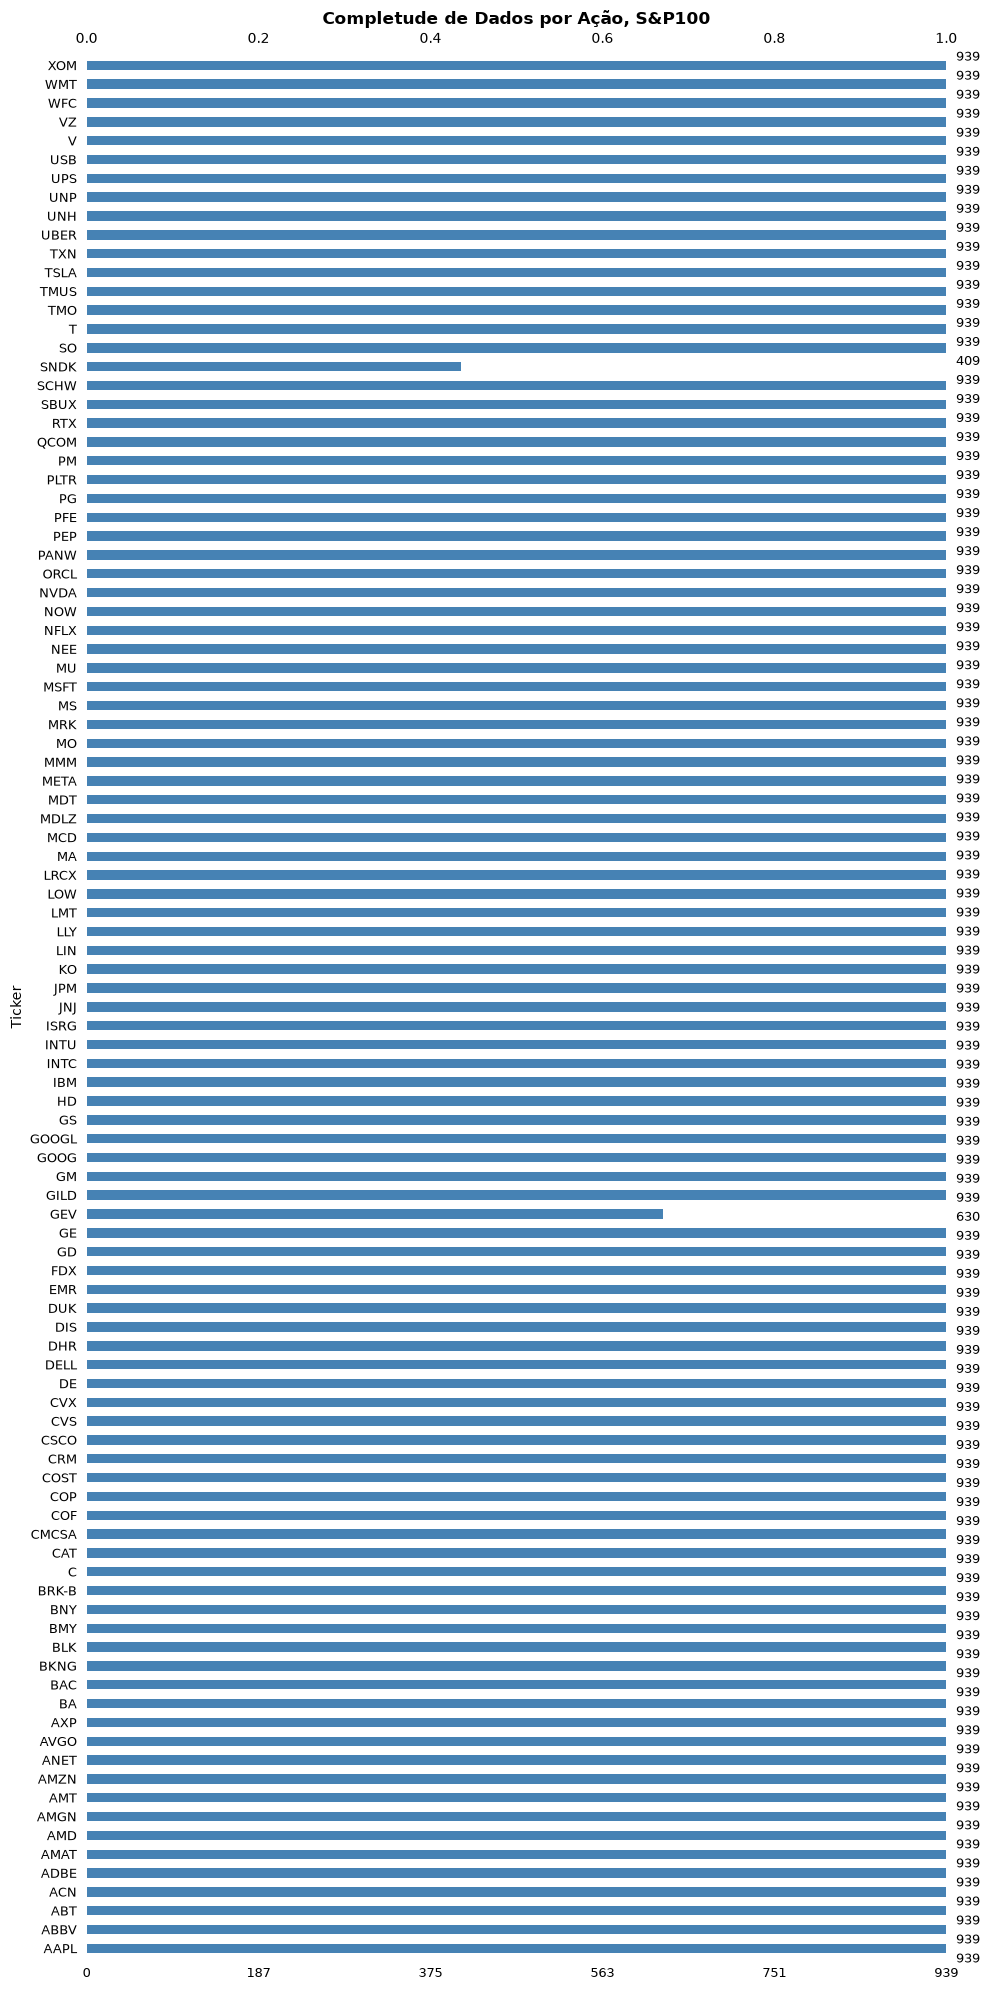

=== DADOS FALTANTES,IBOVESPA ===
Total de ações: 76
Ações sem nenhum dado faltante: 75
Ações com algum dado faltante: 1

Ações com até 5% de dados faltantes:
Series([], dtype: float64)

Ações com mais de 5% de dados faltantes:
Ticker
NATU3.SA    66.03
dtype: float64


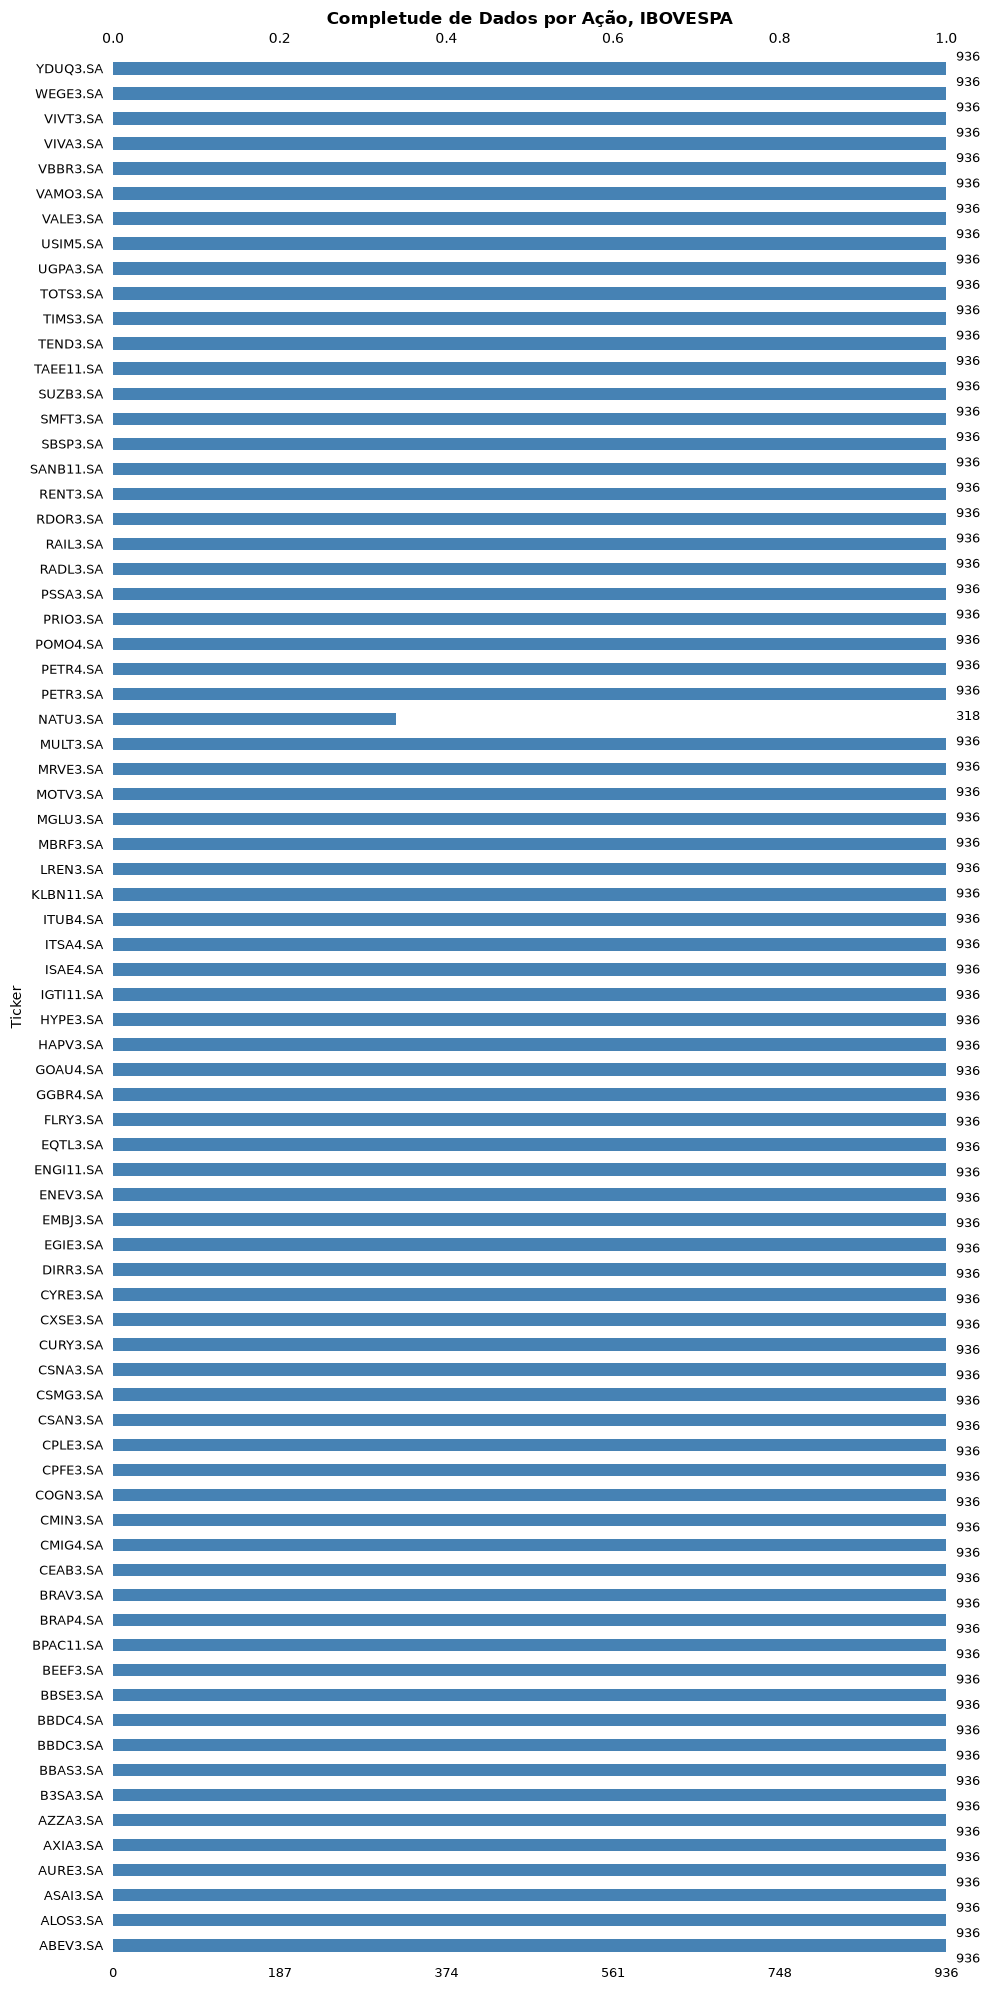

In [212]:
# ══════════════════════════════════════════════════════
# DIAGNÓSTICO DE DADOS FALTANTES, S&P100
# ══════════════════════════════════════════════════════

# Contagem e percentual de nulos por ação
nulos_sp = dados_sp100.isnull().sum()
pct_nulos = (nulos_sp / len(dados_sp100) * 100).round(2)
print('=== DADOS FALTANTES,S&P100 ===')
print(f'Total de ações: {dados_sp100.shape[1]}')
print(f'Ações sem nenhum dado faltante: {(pct_nulos == 0).sum()}')
print(f'Ações com algum dado faltante: {(pct_nulos > 0).sum()}')
print("\nAções com até 5% de dados faltantes:")
print(pct_nulos[pct_nulos.between(0, 5, inclusive='right')])
print(f'\nAções com mais de 5% de dados faltantes:')
print(pct_nulos[pct_nulos > 5].sort_values(ascending=False))

# Visualização,mapa de calor de dados faltantes
fig, ax = plt.subplots(figsize=(10, 20))
msno.bar(dados_sp100, ax=ax, color='steelblue', fontsize=9)
ax.set_title('Completude de Dados por Ação, S&P100', fontweight='bold')
plt.tight_layout()
plt.savefig('missing_sp100.png', dpi=150)
plt.show()

# ══════════════════════════════════════════════════════
# DIAGNÓSTICO DE DADOS FALTANTES, IBOVESPA
# ══════════════════════════════════════════════════════

# Contagem e percentual de nulos por ação
nulos_sp = dados_ibov.isnull().sum()
pct_nulos = (nulos_sp / len(dados_ibov) * 100).round(2)
print('=== DADOS FALTANTES,IBOVESPA ===')
print(f'Total de ações: {dados_ibov.shape[1]}')
print(f'Ações sem nenhum dado faltante: {(pct_nulos == 0).sum()}')
print(f'Ações com algum dado faltante: {(pct_nulos > 0).sum()}')
print("\nAções com até 5% de dados faltantes:")
print(pct_nulos[pct_nulos.between(0, 5, inclusive='right')])
print(f'\nAções com mais de 5% de dados faltantes:')
print(pct_nulos[pct_nulos > 5].sort_values(ascending=False))

# Visualização,mapa de calor de dados faltantes
fig, ax = plt.subplots(figsize=(10, 20))
msno.bar(dados_ibov, ax=ax, color='steelblue', fontsize=9)
ax.set_title('Completude de Dados por Ação, IBOVESPA', fontweight='bold')
plt.tight_layout()
plt.savefig('missing_ibov.png', dpi=150)
plt.show()


IBOVESPA
Total de ações originais: 76
Total de ações mantidas:  75

S&P100
Total de ações originais: 101
Total de ações mantidas:  99

Retornos finais,IBOV: (935, 75)
Retornos finais,S&P100: (938, 99)


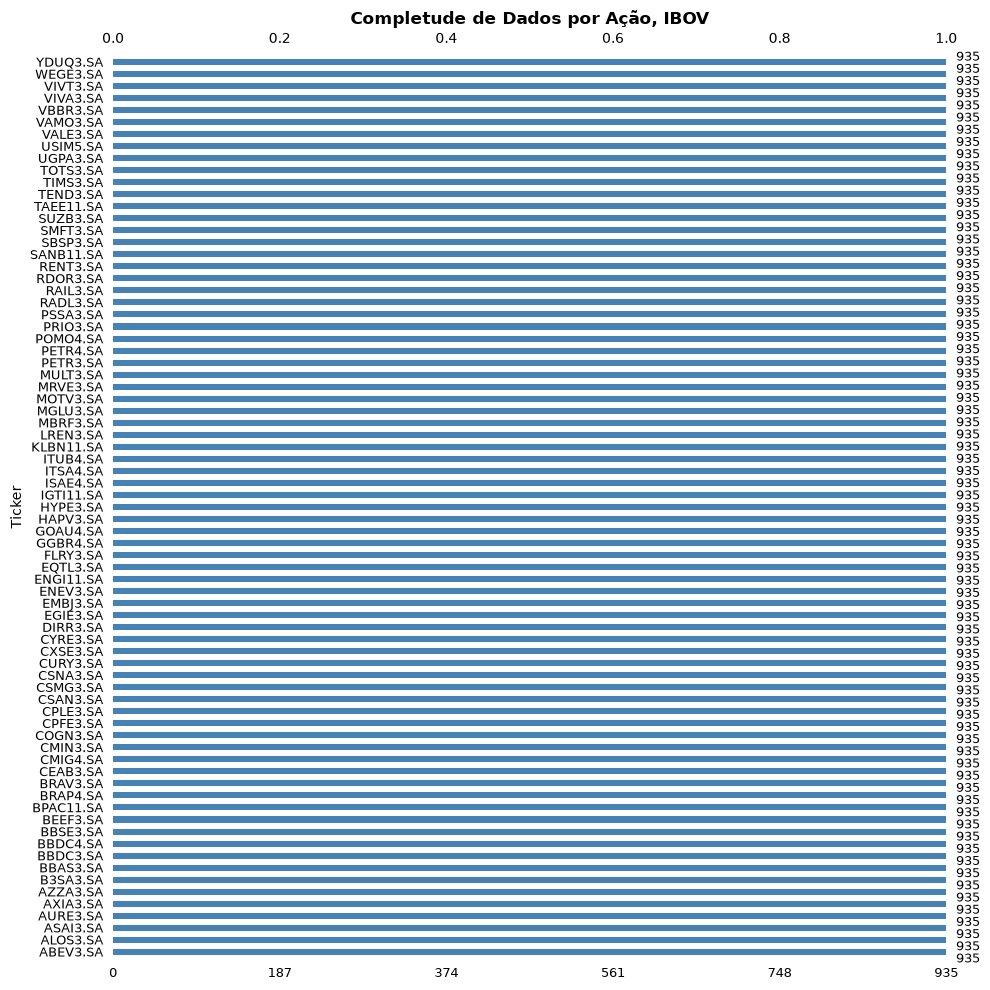

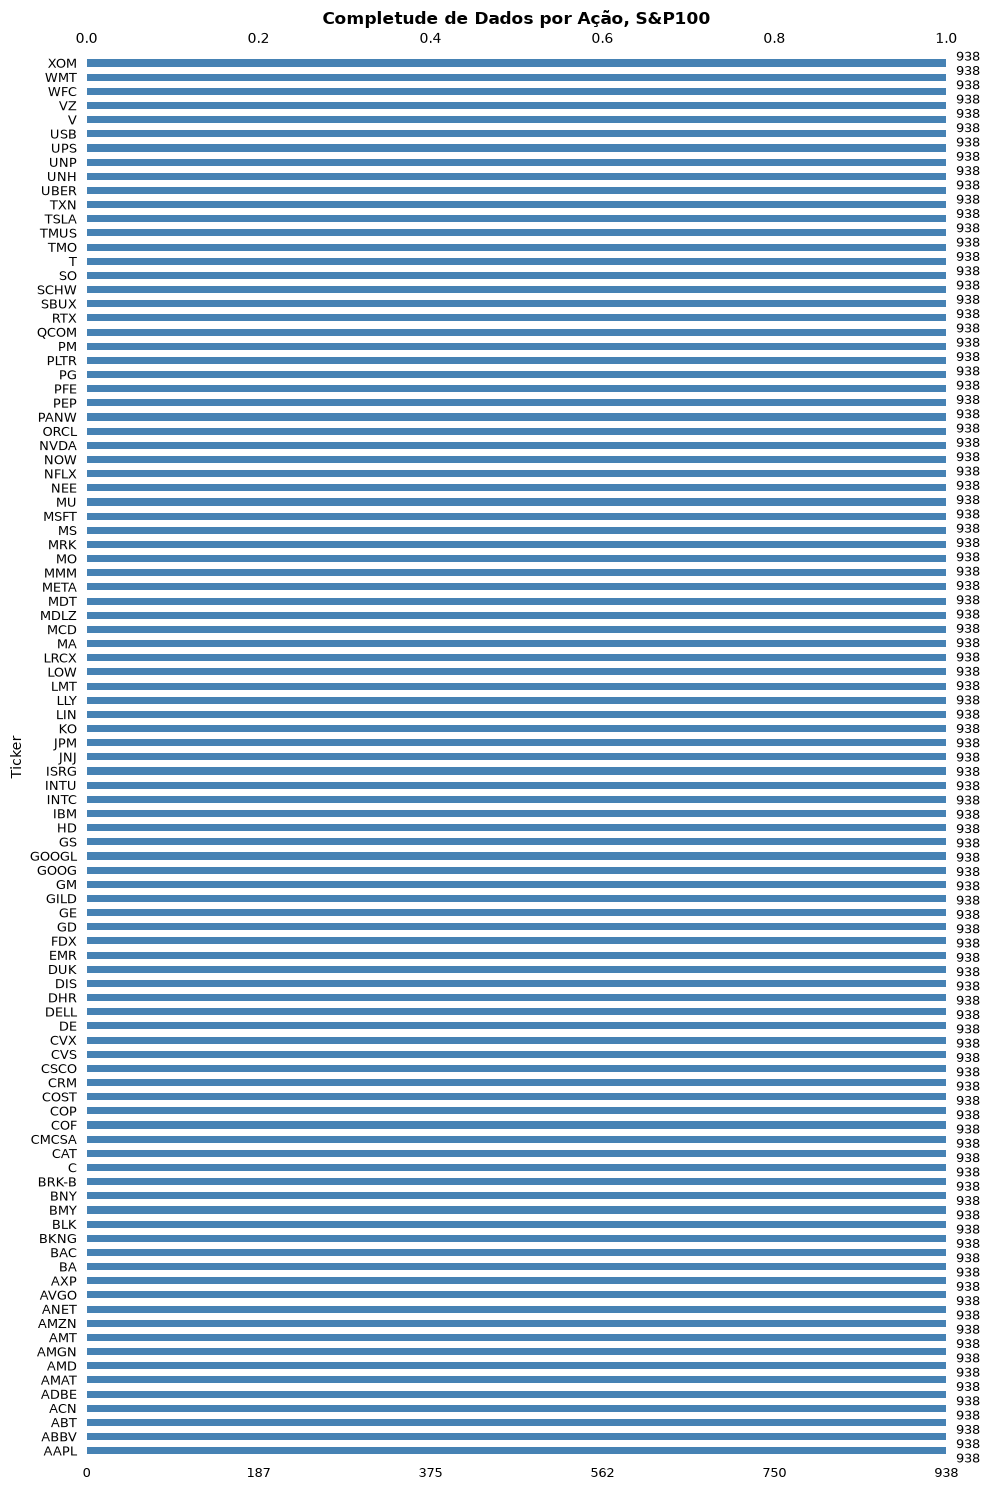

In [221]:
# ══════════════════════════════════════════════════════
# TRATAMENTO DE DADOS FALTANTES
# ══════════════════════════════════════════════════════

# 1. Definir o limite máximo tolerado de NaNs (ex: 5%)
limite_remocao = 5.0  

# 2. Calcular a porcentagem de nulos de CADA AÇÃO (por coluna)
pct_nulos_sp100 = dados_sp100.isna().mean() * 100
pct_nulos_ibov = dados_ibov.isna().mean() * 100

# 3. Filtrar as ações que estão DENTRO do limite e extrair os nomes
acoes_validas_sp100 = pct_nulos_sp100[pct_nulos_sp100 <= limite_remocao].index
acoes_validas_ibov = pct_nulos_ibov[pct_nulos_ibov <= limite_remocao].index

# 4 Preencher dados faltantes (<5%) restantes com forward fill
dados_sp100_clean = dados_sp100_clean.ffill() # ffill preenche com o último valor disponível 
dados_ibov_clean = dados_ibov_clean.ffill()

# 5. Criar o novo DataFrame filtrado contendo apenas as ações válidas
dados_sp100_clean = dados_sp100[acoes_validas_sp100]
dados_ibov_clean = dados_ibov[acoes_validas_ibov]
print ("IBOVESPA")
print(f"Total de ações originais: {dados_ibov.shape[1]}")
print(f"Total de ações mantidas:  {len(acoes_validas_ibov)}")

print ("\nS&P100")
print(f"Total de ações originais: {dados_sp100.shape[1]}")
print(f"Total de ações mantidas:  {len(acoes_validas_sp100)}")

# 6. Verificar se ainda há nulos (linhas iniciais podem ter NaN)
dados_sp100_clean = dados_sp100_clean.dropna(how='all')
dados_ibov_clean = dados_ibov_clean.dropna(how='all')

# Recalcular retornos com dados limpos
ret_sp100_clean = np.log(dados_sp100_clean / dados_sp100_clean.shift(1)).dropna()
ret_ibov_clean = np.log(dados_ibov_clean / dados_ibov_clean.shift(1)).dropna()
print(f'\nRetornos finais,IBOV: {ret_ibov_clean.shape}')
print(f'Retornos finais,S&P100: {ret_sp100_clean.shape}')

# Visualização, mapa de calor de dados completos após limpeza
fig, ax = plt.subplots(figsize=(10, 10))
msno.bar(ret_ibov_clean, ax=ax, color='steelblue', fontsize=9)
ax.set_title('Completude de Dados por Ação, IBOV', fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 15))
msno.bar(ret_sp100_clean, ax=ax, color='steelblue', fontsize=9)
ax.set_title('Completude de Dados por Ação, S&P100', fontweight='bold')
plt.tight_layout()
plt.show()

In [214]:
# ══════════════════════════════════════════════════════
#Identificação de Outliers nos Retornos
# ══════════════════════════════════════════════════════

# Detectar retornos extremos por ação
limite_outlier = 0.15 # ±15% em um dia,ajuste conforme necessário
outliers_sp = (ret_sp100_clean.abs() > limite_outlier).sum()
print('Ações com retornos diários > 15% (S&P100):')
print(outliers_sp[outliers_sp > 0].sort_values(ascending=False).head(15))

outliers_ibov = (ret_ibov_clean.abs() > limite_outlier).sum()
print('\nAções com retornos diários > 15% (IBOV):')
print(outliers_ibov[outliers_ibov > 0].sort_values(ascending=False).head(15))

# ══════════════════════════════════════════════════════
#Aqui Investiga uma ação específica suspeita
# ══════════════════════════════════════════════════════
acao_suspeita = 'TSLA' # Substituir por qualquer ação do S&P100 ou IBOVESPA que você queira investigar
if acao_suspeita in ret_sp100_clean.columns:
    retornos_acao = ret_sp100_clean[acao_suspeita]
    dias_extremos = retornos_acao[retornos_acao.abs() > limite_outlier]
    print(f'\nDias com retorno extremo,{acao_suspeita}:')
    formato = len(dias_extremos)
    print(dias_extremos.sort_values(key=abs, ascending=False))
    print(f'Quantidade de dias extremos: {formato}')

Ações com retornos diários > 15% (S&P100):
Ticker
PLTR    9
DELL    7
MU      5
INTC    5
TSLA    5
NVDA    4
ANET    4
AMD     4
AVGO    3
UNH     3
CVS     2
CRM     2
META    2
SBUX    2
LRCX    2
dtype: int64

Ações com retornos diários > 15% (IBOV):
Ticker
HAPV3.SA    6
CEAB3.SA    5
MGLU3.SA    4
YDUQ3.SA    3
RADL3.SA    2
TEND3.SA    2
MBRF3.SA    2
BRAV3.SA    2
BEEF3.SA    1
BBDC4.SA    1
AZZA3.SA    1
AXIA3.SA    1
LREN3.SA    1
CYRE3.SA    1
CSAN3.SA    1
dtype: int64

Dias com retorno extremo,TSLA:
Date
2025-04-09    0.204491
2024-10-24    0.198187
2025-03-10   -0.167546
2026-07-23   -0.156931
2025-06-05   -0.153849
Name: TSLA, dtype: float64
Quantidade de dias extremos: 5


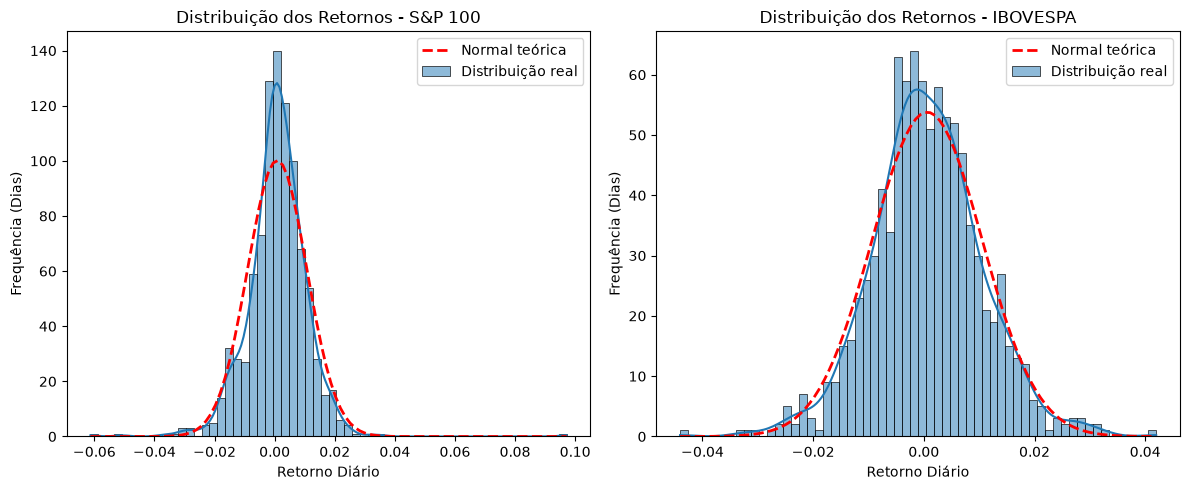

       ANÁLISE ESTATÍSTICA DE RISCO E DISTRIBUIÇÃO

--- ASSIMETRIA (SKEWNESS) ---
S&P 100:  0.35  (Normal = 0)
IBOVESPA: 0.03  (Normal = 0)

--- CURTOSE EM EXCESSO (KURTOSIS) ---
S&P 100:  12.14  (Normal = 0)
IBOVESPA: 1.10  (Normal = 0)

🔍 INTERPRETAÇÃO DOS RESULTADOS:
• Curtose > 0 (Fat Tails): Ambos os índices apresentam caudas gordas.
  Eventos extremos (choques e crises) ocorrem com frequência superior à prevista pela distribuição Normal.
• Assimetria < 0 (Negative Skew): Distribuição levemente inclinada à esquerda.
  Indica probabilidade maior de variações negativas intensas (quedas repentinas) do que de altas extremas.


In [215]:
# ══════════════════════════════════════════════════════
# Gráfico de distribuição de retornos vs. curva normal
# ══════════════════════════════════════════════════════
plt.figure(figsize=(12, 5))


# Retornos do índice S&P100
plt.subplot(1, 2, 1) # divides the figure in 1 row and 2 columns, and selects the first plot (the left side) as the active drawing area
sns.histplot(ret_idx_sp, bins=60, kde=True, color='navy',label='Distribuição real')
mu, sigma = ret_idx_sp["^OEX"].mean(), ret_idx_sp["^OEX"].std()
x = np.linspace(ret_idx_sp.min(), ret_idx_sp.max(), 100)
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2) # Fórmula da densidade de probabilidade da Normal
fator_escala = len(ret_idx_sp["^OEX"]) * (ret_idx_sp["^OEX"].max() - ret_idx_sp["^OEX"].min()) / 60
plt.plot(x, pdf * fator_escala, 'r--', lw=2, label='Normal teórica') # Adiciona curva normal teórica
plt.title('Distribuição dos Retornos - S&P 100')
plt.xlabel('Retorno Diário')
plt.ylabel('Frequência (Dias)')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(ret_idx_ib, bins=60, kde=True, color='green', label='Distribuição real')
mu2, sigma2 = ret_idx_ib["^BVSP"].mean(), ret_idx_ib["^BVSP"].std()
x2 = np.linspace(ret_idx_ib.min(), ret_idx_ib.max(), 100)
pdf2 = (1 / (sigma2 * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x2 - mu2) / sigma2) ** 2) #Calculando a densidade de probabilidade da Normal
fator_escala2 = len(ret_idx_ib["^BVSP"]) * (ret_idx_ib["^BVSP"].max() - ret_idx_ib["^BVSP"].min()) / 60
plt.plot(x2, pdf2 * fator_escala2, 'r--', lw=2, label='Normal teórica') # Adiciona curva normal teórica


plt.title('Distribuição dos Retornos - IBOVESPA')
plt.xlabel('Retorno Diário')
plt.ylabel('Frequência (Dias)')
plt.legend()

plt.tight_layout()
plt.savefig('distribuicao_retornos.png', dpi=150)
plt.show()

# ══════════════════════════════════════════════════════
# CÁLCULO E EXIBIÇÃO DA ASSIMETRIA E CURTOSE
# ══════════════════════════════════════════════════════

# Assimetria (Skewness)
skew_sp = ret_idx_sp["^OEX"].skew()
skew_ib = ret_idx_ib["^BVSP"].skew()

# Curtose em Excesso (Kurtosis)
kurt_sp = ret_idx_sp["^OEX"].kurtosis()
kurt_ib = ret_idx_ib["^BVSP"].kurtosis()


print("       ANÁLISE ESTATÍSTICA DE RISCO E DISTRIBUIÇÃO")
print("\n--- ASSIMETRIA (SKEWNESS) ---")
print(f"S&P 100:  {skew_sp:.2f}  (Normal = 0)")
print(f"IBOVESPA: {skew_ib:.2f}  (Normal = 0)")

print("\n--- CURTOSE EM EXCESSO (KURTOSIS) ---")
print(f"S&P 100:  {kurt_sp:.2f}  (Normal = 0)")
print(f"IBOVESPA: {kurt_ib:.2f}  (Normal = 0)")
print("=" * 55)

# INTERPRETAÇÃO FINANCEIRA
print("\n🔍 INTERPRETAÇÃO DOS RESULTADOS:")
print("• Curtose > 0 (Fat Tails): Ambos os índices apresentam caudas gordas.")
print("  Eventos extremos (choques e crises) ocorrem com frequência superior à prevista pela distribuição Normal.")
print("• Assimetria < 0 (Negative Skew): Distribuição levemente inclinada à esquerda.")
print("  Indica probabilidade maior de variações negativas intensas (quedas repentinas) do que de altas extremas.")

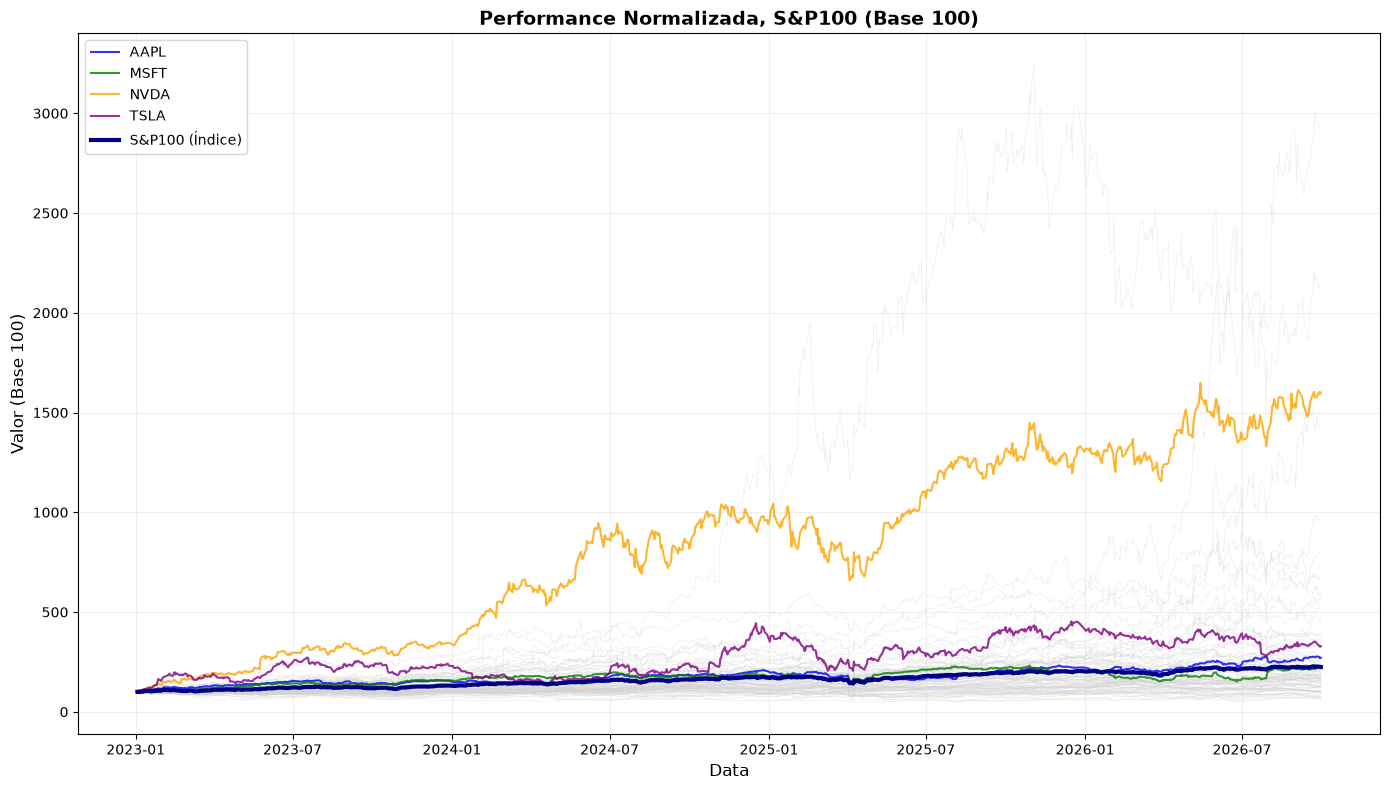

In [ ]:
# ══════════════════════════════════════════════════════
# Performance Normalizada SP100
# ══════════════════════════════════════════════════════

# Performance normalizada: todos começam em 100 no início do período
precos_norm_sp = (dados_sp100_clean / dados_sp100_clean.iloc[0] * 100)
indice_norm_sp = (indice_sp100 / indice_sp100.iloc[0] * 100)

plt.figure(figsize=(14, 8))

# Ações individuais em cinza claro (fundo)
for col in precos_norm_sp.columns:
    plt.plot(precos_norm_sp.index, precos_norm_sp[col], color='lightgray', linewidth=0.5, alpha=0.4)

# Destacar algumas ações relevantes
destaques = ['AAPL', 'MSFT', 'NVDA', 'TSLA']
cores_dest = ['blue', 'green', 'orange', 'purple']
for acao, cor in zip(destaques, cores_dest):
    if acao in precos_norm_sp.columns:
        plt.plot(precos_norm_sp.index, precos_norm_sp[acao], color=cor, linewidth=1.5, label=acao, alpha=0.8)

# Índice em destaque total
plt.plot(indice_norm_sp.index, indice_norm_sp, color='navy', linewidth=3, label='S&P100 (Índice)')

# Marcar eventos importantes

data_covid_inicio = pd.to_datetime('2020-03-23')
data_covid_fim = pd.to_datetime('2020-03-25')
#plt.axvline(data_covid_inicio, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
#plt.text(data_covid_fim, precos_norm_sp.max().max()*0.85, 'Mínimo\nCOVID', color='red', fontsize=9)

data_crise_juros_inicio = pd.to_datetime('2022-01-03')
data_crise_juros_fim = pd.to_datetime('2022-02-01')
#plt.axvline(data_crise_juros_inicio, color='darkred', linestyle=':', linewidth=1.5, alpha=0.7)
#plt.text(data_crise_juros_fim, precos_norm_sp.max().max()*0.70, 'Início\nCrise Juros', color='darkred', fontsize=9)

plt.title('Performance Normalizada, S&P100 (Base 100)', fontsize=14, fontweight='bold')
plt.ylabel('Valor (Base 100)', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('performance_normalizada_sp100.png', dpi=150)
plt.show()

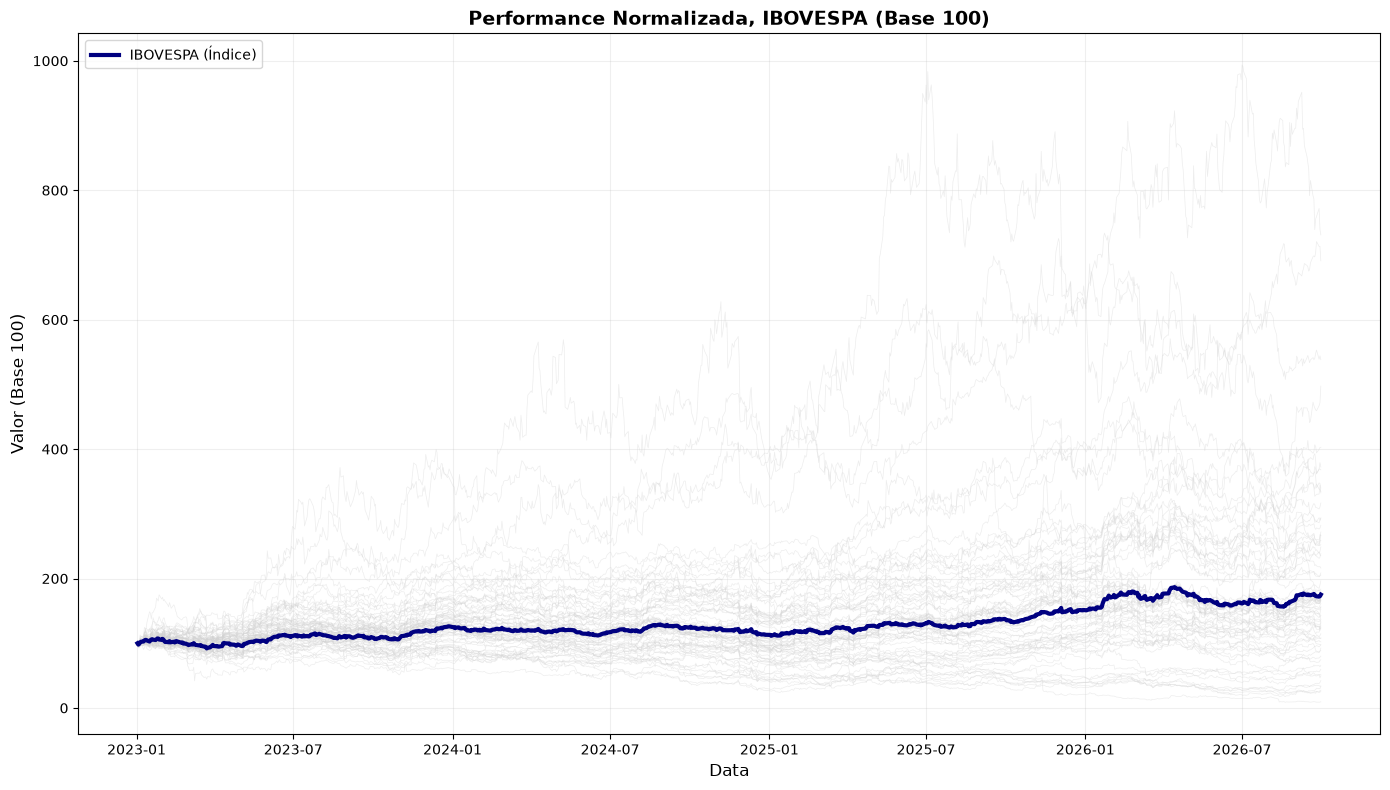

In [222]:
# ══════════════════════════════════════════════════════
# Performance Normalizada IBOVESPA
# ══════════════════════════════════════════════════════

# Performance normalizada: todos começam em 100 no início do período
precos_norm_ib = (dados_ibov_clean / dados_ibov_clean.iloc[0] * 100)
indice_norm_ib = (indice_ibov / indice_ibov.iloc[0] * 100)

plt.figure(figsize=(14, 8))

# Ações individuais em cinza claro (fundo)
for col in precos_norm_ib.columns:
    plt.plot(precos_norm_ib.index, precos_norm_ib[col], color='lightgray', linewidth=0.5, alpha=0.4)

# Destacar algumas ações relevantes
destaques = ['AAPL', 'MSFT', 'NVDA', 'TSLA']
cores_dest = ['blue', 'green', 'orange', 'purple']
for acao, cor in zip(destaques, cores_dest):
    if acao in precos_norm_ib.columns:
        plt.plot(precos_norm_ib.index, precos_norm_ib[acao], color=cor, linewidth=1.5, label=acao, alpha=0.8)

# Índice em destaque total
plt.plot(indice_norm_ib.index, indice_norm_ib, color='navy', linewidth=3, label='IBOVESPA (Índice)')

# Marcar eventos importantes

data_covid_inicio = pd.to_datetime('2020-03-23')
data_covid_fim = pd.to_datetime('2020-03-25')
#plt.axvline(data_covid_inicio, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
#plt.text(data_covid_fim, precos_norm_ib.max().max()*0.85, 'Mínimo\nCOVID', color='red', fontsize=9)

data_crise_juros_inicio = pd.to_datetime('2022-01-03')
data_crise_juros_fim = pd.to_datetime('2022-02-01')
#plt.axvline(data_crise_juros_inicio, color='darkred', linestyle=':', linewidth=1.5, alpha=0.7)
#plt.text(data_crise_juros_fim, precos_norm_ib.max().max()*0.70, 'Início\nCrise Juros', color='darkred', fontsize=9)

plt.title('Performance Normalizada, IBOVESPA (Base 100)', fontsize=14, fontweight='bold')
plt.ylabel('Valor (Base 100)', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('performance_normalizada_ibovespa.png', dpi=150)
plt.show()